In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
data_dir = Path("../disdata/RETC")  # adjust to your folder

# Map: filename -> label (used only for tracking, not required downstream)
files = {
    "0518": data_dir / "retc_0518.csv", 
    "19": data_dir / "retc_19.csv",
    "20": data_dir / "retc_20.csv",
    "21": data_dir / "retc_21.csv",
    "22": data_dir / "retc_22.csv",
    "23": data_dir / "retc_23.csv",
}

In [3]:
def load_retc_year_file(path, n_expected_cols=12, encoding="utf-8"):
    """
    Auto-detects whether a RETC year file is:
    (a) a plain comma CSV matching the 0518 schema, or
    (b) the pipe-delimited schema with a tab-joined leading row id
    """
    with open(path, "r", encoding=encoding, errors="replace") as f:
        first_line = f.readline().lstrip("\ufeff").rstrip("\n")

    if "|" in first_line:
        # pipe/tab hybrid format
        return _parse_pipe_hybrid(path, n_expected_cols, encoding), "pipe_hybrid"
    else:
        # plain comma CSV, same shape as 0518
        df = pd.read_csv(path, encoding=encoding)
        return df, "comma_0518_style"


def _parse_pipe_hybrid(path, n_expected_cols, encoding):
    with open(path, "r", encoding=encoding, errors="replace") as f:
        lines = f.readlines()

    header = lines[0].lstrip("\ufeff").rstrip("\n").split("|")
    header = [h.strip() for h in header]

    rows, bad_rows = [], []
    for i, line in enumerate(lines[1:], start=2):
        line = line.rstrip("\n")
        if not line.strip():
            continue
        parts = line.split("|")
        first_split = parts[0].split("\t", 1)
        row_id, first_field = first_split if len(first_split) == 2 else (None, parts[0])
        fields = [first_field] + parts[1:]
        if len(fields) != n_expected_cols:
            bad_rows.append((i, line))
            continue
        rows.append([row_id] + fields)

    df = pd.DataFrame(rows, columns=["row_id"] + header)
    if bad_rows:
        print(f"{path.name}: {len(bad_rows)} malformed rows skipped")
        for i, l in bad_rows[:3]:
            print(f"  line {i}: {l[:150]}")
    return df

In [4]:
# Check the format of each year file individually before combining
for year_key in ["19", "20", "21", "22", "23"]:
    df, fmt = load_retc_year_file(files[year_key])
    print(f"{year_key}: format={fmt}, shape={df.shape}")
    print(df.columns.tolist())
    print(df.head(2))
    print("---")

19: format=comma_0518_style, shape=(18207, 8)
['_id', 'Tipo de Fuente', 'Contaminante', 'Año', 'Emisión (Toneladas)', 'Región', 'Provincia', 'Comuna']
   _id                        Tipo de Fuente   Contaminante   Año  \
0    1  Combustión de Leña Residencial Rural  Carbono Negro  2019   
1    2  Combustión de Leña Residencial Rural  Carbono Negro  2019   

   Emisión (Toneladas)       Región    Provincia       Comuna  
0             3.037223  Antofagasta  Antofagasta  Antofagasta  
1             0.104612  Antofagasta  Antofagasta   Mejillones  
---
20: format=comma_0518_style, shape=(17004, 8)
['_id', 'Tipo de Fuente', 'Contaminante', 'Año', 'Emisión (Toneladas)', 'Región', 'Provincia', 'Comuna']
   _id                        Tipo de Fuente   Contaminante   Año  \
0    1  Combustión de Leña Residencial Rural  Carbono Negro  2020   
1    2  Combustión de Leña Residencial Rural  Carbono Negro  2020   

   Emisión (Toneladas)       Región    Provincia       Comuna  
0             2.955552

/tmp/ipykernel_448644/3576635117.py:15: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, encoding=encoding)


23: format=comma_0518_style, shape=(686115, 13)
['Unnamed: 0', 'tipo_fuente', 'id_tipo_fuente', 'contaminantes', 'id_contaminantes', 'año', 'cantidad_toneladas', 'region', 'provincia', 'comuna', 'id_comuna', 'Lat', 'Lon']
   Unnamed: 0                            tipo_fuente  id_tipo_fuente  \
0           0  Combustión de Leña Residencial Urbana              27   
1           1  Combustión de Leña Residencial Urbana              27   

                    contaminantes  id_contaminantes   año  cantidad_toneladas  \
0             Monóxido de carbono                73  2023          197.903057   
1  Compuestos Orgánicos Volátiles                35  2023          153.990064   

      region provincia  comuna  id_comuna  Lat  Lon  
0  Araucanía    Cautín  Temuco       9101  NaN  NaN  
1  Araucanía    Cautín  Temuco       9101  NaN  NaN  
---


In [5]:
# Creating one common structure for the CSVs
common_cols = [
    "source_file", "tipo_fuente", "id_tipo_fuente", "contaminante", "id_contaminante",
    "ano", "cantidad_toneladas", "region", "provincia", "comuna",
    "id_comuna", "lat", "lon"
]

schema_A_rename = {
    "Tipo de Fuente": "tipo_fuente",
    "Contaminante": "contaminante",
    "Año": "ano",
    "Emisión (Toneladas)": "cantidad_toneladas",
    "Región": "region",
    "Provincia": "provincia",
    "Comuna": "comuna",
}

schema_B_rename = {
    "tipo_fuente": "tipo_fuente",
    "id_tipo_fuente": "id_tipo_fuente",
    "contaminantes": "contaminante",
    "id_contaminantes": "id_contaminante",
    "año": "ano",
    "cantidad_toneladas": "cantidad_toneladas",
    "region": "region",
    "provincia": "provincia",
    "comuna": "comuna",
    "id_comuna": "id_comuna",
    "Lat": "lat",
    "Lon": "lon",
}

def harmonise(df, rename_map, source_key):
    df = df.rename(columns=rename_map)
    for col in common_cols:
        if col not in df.columns:
            df[col] = np.nan
    df = df[common_cols].copy()
    df["source_file"] = source_key
    return df

frames = []
for year_key in ["0518", "19", "20", "21", "22", "23"]:
    df, fmt = load_retc_year_file(files[year_key])
    if "Tipo de Fuente" in df.columns:
        harmonised = harmonise(df, schema_A_rename, year_key)
    else:
        harmonised = harmonise(df, schema_B_rename, year_key)
    frames.append(harmonised)
    print(f"{year_key}: format={fmt}, schema={'A' if 'Tipo de Fuente' in df.columns else 'B'}, rows={len(harmonised)}")

0518: format=comma_0518_style, schema=A, rows=143332
19: format=comma_0518_style, schema=A, rows=18207
20: format=comma_0518_style, schema=A, rows=17004
21: format=pipe_hybrid, schema=B, rows=684638
22: format=pipe_hybrid, schema=B, rows=660183


/tmp/ipykernel_448644/3576635117.py:15: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, encoding=encoding)


23: format=comma_0518_style, schema=B, rows=686115


In [6]:
# Fix decimal commas, finalise dtypes, concatenate and save
combined = pd.concat(frames, ignore_index=True)

# pipe-hybrid files (21, 22); already float from the comma-CSV files
def fix_decimal(val):
    if isinstance(val, str):
        return float(val.replace(",", "."))
    return val

combined["cantidad_toneladas"] = combined["cantidad_toneladas"].apply(fix_decimal)
combined["ano"] = pd.to_numeric(combined["ano"], errors="coerce")
combined["lat"] = pd.to_numeric(combined["lat"], errors="coerce")
combined["lon"] = pd.to_numeric(combined["lon"], errors="coerce")

# RETC has no sub-annual date field, only calendar year. Given the study's
# fire season peak is Nov-Mar, a calendar year's fire-related emissions predominantly reflect the fire year ending in that calendar year (i.e.
# calendar year X maps to fire year (X-1)-X), consistent with the July-June fire year convention used elsewhere in the dissertation. 
# This is an assumption, not a measurement, since RETC provides no month field.
combined["fire_year"] = combined["ano"].apply(lambda y: f"{int(y)-1}-{int(y)}" if pd.notna(y) else np.nan)

print(combined.shape)
print(combined["source_file"].value_counts())
print(combined["ano"].value_counts().sort_index())
print(combined.dtypes)
combined.head()

combined.to_csv("../outputs/retc_combined_2005_2023.csv", index=False)

(2209479, 14)
source_file
23      686115
21      684638
22      660183
0518    143332
19       18207
20       17004
Name: count, dtype: int64
ano
2005      7321
2006      7293
2007      7265
2008      8924
2009      8980
2010     10442
2011     10658
2012     10724
2013     10758
2014     10839
2015     10875
2016     10884
2017     11051
2018     17318
2019     18207
2020     17004
2021    684638
2022    660183
2023    686115
Name: count, dtype: int64
source_file            object
tipo_fuente            object
id_tipo_fuente         object
contaminante           object
id_contaminante        object
ano                     int64
cantidad_toneladas    float64
region                 object
provincia              object
comuna                 object
id_comuna              object
lat                   float64
lon                   float64
fire_year              object
dtype: object


## Trim Data to My Study Region & Inspect the Columns

In [7]:
# Start inspecting for my study region 
combined = pd.read_csv("../outputs/retc_combined_2005_2023.csv")

# study regions per project scope: Ñuble, Biobío, Araucanía
# note: Ñuble was only split out administratively from Biobío around 2019/2020, so pre-split years likely report it under "Biobío" 
study_regions = ["Ñuble", "Biobío", "Araucanía"]

print("All region values in file:")
print(combined["region"].value_counts(dropna=False))

All region values in file:
region
Araucanía                                  388249
Biobío                                     325180
Ñuble                                      217359
Maule                                      213978
Los Lagos                                  202582
Metropolitana                              188861
Libertador Gral. Bernardo O'Higgins        182025
Valparaíso                                 131209
Los Ríos                                   102643
Aysén del Gral. Carlos Ibáñez del Campo     61012
Coquimbo                                    51510
Atacama                                     33399
Magallanes y de la Antártica Chilena        32585
Arica y Parinacota                          29928
Antofagasta                                 21957
Tarapacá                                    18792
Metropolitana de Santiago                    4589
La Araucanía                                 3621
Name: count, dtype: int64


In [8]:
# Region filter

# normalise whitespace/case for matching, keep original column intact
combined["region_clean"] = combined["region"].astype(str).str.strip()
combined["region_clean"] = combined["region_clean"].replace({"La Araucanía": "Araucanía"})

region_filtered = combined[combined["region_clean"].isin(study_regions)].copy()

print(region_filtered.shape)
print(region_filtered["region_clean"].value_counts())
print(region_filtered["source_file"].value_counts())

(934409, 15)
region_clean
Araucanía    391870
Biobío       325180
Ñuble        217359
Name: count, dtype: int64
source_file
23     303011
21     294735
22     287849
518     39178
19       4923
20       4713
Name: count, dtype: int64


In [9]:
# Inspect Fire sources
print("Unique tipo_fuente values:")
for v in sorted(region_filtered["tipo_fuente"].dropna().unique()):
    print(f"  {v}")

Unique tipo_fuente values:
  Combustión de Leña Residencial Rural
  Combustión de Leña Residencial Urbana
  Combustión de leña Rural Urbana
  Incendios Forestales
  Incendios Urbanos
  Quemas Agricolas
  Quemas Agrícolas


In [10]:
# Inspect Contaminant Values & Specifically the PM2.5 Name
print("Unique contaminante values:")
for v in sorted(region_filtered["contaminante"].dropna().unique()):
    print(f"  {v}")

print("\nLikely PM2.5-related entries:")
pm25_candidates = region_filtered["contaminante"].dropna().unique()
pm25_candidates = [v for v in pm25_candidates if "2" in v.replace(",", ".").replace(" ", "") or "PM" in v.upper() or "MP" in v.upper()]
print(pm25_candidates)

Unique contaminante values:
  Arsénico
  Carbono Negro
  Compuestos Orgánicos Volátiles
  Dióxido de azufre (SO2)
  Dióxido de carbono (CO2)
  MP10
  MP2,5
  Material particulado
  Mercurio
  Metano (CH4)
  Monóxido de carbono
  NOx
  NOx 
  Nitrógeno amoniacal (o NH3)
  Oxido Nitroso
  Plomo

Likely PM2.5-related entries:
['Compuestos Orgánicos Volátiles', 'Dióxido de azufre (SO2)', 'Dióxido de carbono (CO2)', 'MP10', 'MP2,5']


In [11]:
# Cross-tab of fire-related tipe_fuente against contaminant to see coverage

fire_keywords = ["Incendios Forestales"] #for wildfires
fire_mask = region_filtered["tipo_fuente"].str.contains("|".join(fire_keywords), case=False, na=False)

print(region_filtered.loc[fire_mask, "tipo_fuente"].value_counts())
print("---")
pd.crosstab(
    region_filtered.loc[fire_mask, "tipo_fuente"],
    region_filtered.loc[fire_mask, "contaminante"]
)

tipo_fuente
Incendios Forestales    270367
Name: count, dtype: int64
---


contaminante,Carbono Negro,Compuestos Orgánicos Volátiles,Dióxido de azufre (SO2),Dióxido de carbono (CO2),MP10,"MP2,5",Material particulado,Metano (CH4),Monóxido de carbono,NOx,NOx,Nitrógeno amoniacal (o NH3),Oxido Nitroso
tipo_fuente,,,,,,,,,,,,,
Incendios Forestales,22043,21468,23114,23114,23114,23114,22043,22043,23114,21785,1329,22043,22043


## Looking At % PM2.5 & Wildfires in Different Region Groupings

In [12]:
print(sorted(combined["region"].dropna().unique()))

['Antofagasta', 'Araucanía', 'Arica y Parinacota', 'Atacama', 'Aysén del Gral. Carlos Ibáñez del Campo', 'Biobío', 'Coquimbo', 'La Araucanía', "Libertador Gral. Bernardo O'Higgins", 'Los Lagos', 'Los Ríos', 'Magallanes y de la Antártica Chilena', 'Maule', 'Metropolitana', 'Metropolitana de Santiago', 'Tarapacá', 'Valparaíso', 'Ñuble']


In [13]:
study_region = ["Ñuble", "Biobío", "Araucanía"]
extended_A = study_region + ["Maule", "Libertador Gral. Bernardo O'Higgins"]
extended_B = study_region + ["Maule", "Libertador Gral. Bernardo O'Higgins", "Metropolitana", "Metropolitana de Santiago", "Valparaíso"]

combined["region_clean"] = combined["region"].astype(str).str.strip()

In [14]:
metro_rows = combined[combined["region_clean"].str.contains("Metropolitana", case=False, na=False)]
print(metro_rows.groupby(["region_clean", "ano"]).size())

region_clean               ano 
Metropolitana              2005     1056
                           2006     1077
                           2007     1063
                           2008     1189
                           2009     1217
                           2010     1460
                           2011     1465
                           2012     1456
                           2013     1470
                           2014     1470
                           2015     1477
                           2016     1470
                           2017     1463
                           2018     2270
                           2021    56794
                           2022    57060
                           2023    55404
Metropolitana de Santiago  2019     2371
                           2020     2218
dtype: int64


In [15]:
combined["tipo_fuente_clean"] = combined["tipo_fuente"].replace({
    "Quemas Agricolas": "Quemas Agrícolas",  # merge accent-inconsistent variant
})

fire_related = combined[
    combined["tipo_fuente_clean"].str.contains("Incendio|Quema", case=False, na=False)
]["tipo_fuente_clean"].unique()

print("Fire-related tipo_fuente categories (normalised):")
for v in sorted(fire_related):
    print(f"  {v}")

Fire-related tipo_fuente categories (normalised):
  Incendios Forestales
  Incendios Urbanos
  Quemas Agrícolas


In [16]:
forest_label = "Incendios Forestales"
agri_label = "Quemas Agrícolas"

pm25_all = combined[combined["contaminante"] == "MP2,5"]
pm25_forest_only = pm25_all[pm25_all["tipo_fuente_clean"] == forest_label]

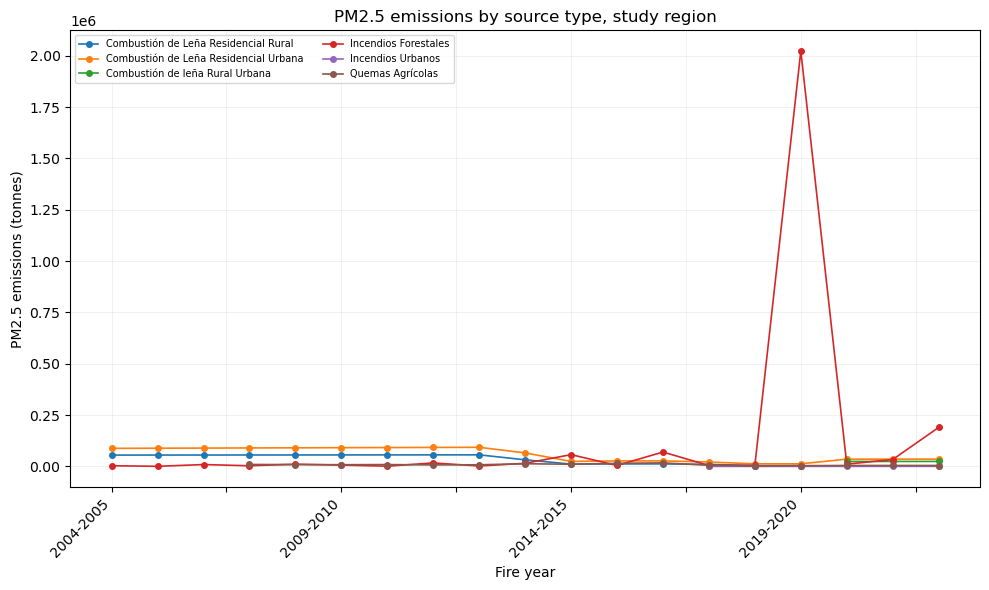

In [17]:
pm25_study_all_sources = combined[
    (combined["contaminante"] == "MP2,5") &
    (combined["region_clean"].isin(study_region))
]

annual_by_source = (
    pm25_study_all_sources.groupby(["fire_year", "tipo_fuente_clean"])["cantidad_toneladas"]
    .sum()
    .unstack("tipo_fuente_clean")
    .sort_index()  # string sort works correctly since years are zero-padded 4-digit
)

fig, ax = plt.subplots(figsize=(10, 6))
annual_by_source.plot(ax=ax, marker="o", linewidth=1.2, markersize=4)
ax.set_xlabel("Fire year")
ax.set_ylabel("PM2.5 emissions (tonnes)")
ax.set_title("PM2.5 emissions by source type, study region")
ax.legend(fontsize=7, loc="upper left", ncol=2)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
ax.grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)
ax.set_axisbelow(True)  # ensures grid sits behind the data, not on top of it
plt.savefig("../outputs/pm25_all_sources_timeseries.png", dpi=400)
plt.show()

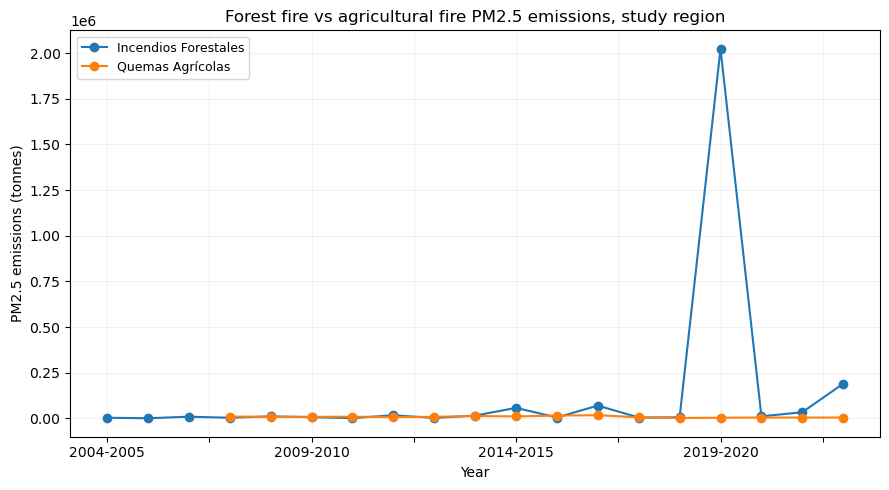

In [18]:
two_cause = annual_by_source[[c for c in [forest_label, agri_label] if c in annual_by_source.columns]]

fig, ax = plt.subplots(figsize=(9, 5))
two_cause.plot(ax=ax, marker="o", linewidth=1.5)
ax.set_xlabel("Year")
ax.set_ylabel("PM2.5 emissions (tonnes)")
ax.set_title("Forest fire vs agricultural fire PM2.5 emissions, study region")
ax.legend(fontsize=9)
plt.tight_layout()
ax.grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)
ax.set_axisbelow(True)  # ensures grid sits behind the data, not on top of it
plt.savefig("../outputs/pm25_forest_vs_agri_timeseries.png", dpi=400)
plt.show()

In [19]:
print("All raw region values before any cleaning:")
print(combined["region"].value_counts(dropna=False))
print()
print("study_regions (early variable):", study_regions)
print("study_region (later variable):", study_region)
print("Are they identical?", study_regions == study_region)

all_clean_regions = sorted(combined["region_clean"].unique())
print("All unique region_clean values in the full file:")
for r in all_clean_regions:
    marker = "✓ IN study_region" if r in study_region else ""
    print(f"  {r!r} {marker}")

print()
unmatched_but_similar = [r for r in all_clean_regions if r not in study_region and
                          any(k in r for k in ["uble", "iob", "rauca"])]
print("Possible near-miss variants not captured by the filter:", unmatched_but_similar)

All raw region values before any cleaning:
region
Araucanía                                  388249
Biobío                                     325180
Ñuble                                      217359
Maule                                      213978
Los Lagos                                  202582
Metropolitana                              188861
Libertador Gral. Bernardo O'Higgins        182025
Valparaíso                                 131209
Los Ríos                                   102643
Aysén del Gral. Carlos Ibáñez del Campo     61012
Coquimbo                                    51510
Atacama                                     33399
Magallanes y de la Antártica Chilena        32585
Arica y Parinacota                          29928
Antofagasta                                 21957
Tarapacá                                    18792
Metropolitana de Santiago                    4589
La Araucanía                                 3621
Name: count, dtype: int64

study_regions (early va

In [20]:
print(f"Rows in combined (all Chile): {len(combined)}")
print(f"Rows in region_filtered (study region only): {len(region_filtered)}")
print(f"Fraction retained: {len(region_filtered) / len(combined):.1%}")
print()
print("region_filtered region_clean counts:")
print(region_filtered["region_clean"].value_counts())
print()
print("Comunas present per region in region_filtered:")
for r in study_region:
    comunas_in_region = sorted(region_filtered[region_filtered["region_clean"] == r]["comuna"].unique())
    print(f"\n{r} ({len(comunas_in_region)} comunas):")
    print(comunas_in_region)

Rows in combined (all Chile): 2209479
Rows in region_filtered (study region only): 934409
Fraction retained: 42.3%

region_filtered region_clean counts:
region_clean
Araucanía    391870
Biobío       325180
Ñuble        217359
Name: count, dtype: int64

Comunas present per region in region_filtered:

Ñuble (21 comunas):
['Bulnes', 'Chillán', 'Chillán Viejo', 'Cobquecura', 'Coelemu', 'Coihueco', 'El Carmen', 'Ninhue', 'Pemuco', 'Pinto', 'Portezuelo', 'Quillón', 'Quirihue', 'Ránquil', 'San Carlos', 'San Fabián', 'San Ignacio', 'San Nicolás', 'Treguaco', 'Yungay', 'Ñiquén']

Biobío (55 comunas):
['Alto Biobío', 'Antuco', 'Arauco', 'Bulnes', 'Cabrero', 'Cañete', 'Chiguayante', 'Chillán', 'Chillán Viejo', 'Cobquecura', 'Coelemu', 'Coihueco', 'Concepción', 'Contulmo', 'Coronel', 'Curanilahue', 'El Carmen', 'Florida', 'Hualpén', 'Hualqui', 'Laja', 'Lebu', 'Los Alamos', 'Los Angeles', 'Los Álamos', 'Lota', 'Mulchén', 'Nacimiento', 'Negrete', 'Ninhue', 'Pemuco', 'Penco', 'Pinto', 'Portezuelo', '

### Inspecting the Spike in 2019-2020

In [21]:
# Isolate the impact of forests with annual_forest_study (still specific to study region)
annual_forest_study = (
    pm25_forest_only[pm25_forest_only["region_clean"].isin(study_region)]
    .groupby("fire_year")["cantidad_toneladas"]
    .sum()
    .sort_index()
)

display_annual_forest = annual_forest_study.round(0).reset_index()
display_annual_forest.columns = ["Fire year", "Forest fire PM2.5 (t)"]
styled_annual = (
    display_annual_forest.style
    .format({"Forest fire PM2.5 (t)": "{:,.0f}"})
    .hide(axis="index")
    .background_gradient(subset=["Forest fire PM2.5 (t)"], cmap="Oranges")
)
styled_annual

Fire year,Forest fire PM2.5 (t)
2004-2005,"3,427"
2005-2006,672
2006-2007,"9,188"
2007-2008,"3,280"
2008-2009,"10,818"
2009-2010,"6,444"
2010-2011,"1,354"
2011-2012,"17,148"
2012-2013,"2,229"
2013-2014,"15,241"


In [22]:
print(pm25_forest_only["fire_year"].dtype)
print(pm25_forest_only["fire_year"].unique()[:10])

object
['2004-2005' '2005-2006' '2006-2007' '2007-2008' '2008-2009' '2009-2010'
 '2010-2011' '2011-2012' '2012-2013' '2013-2014']


In [23]:
spike_fire_year = "2019-2020"
spike_rows = pm25_forest_only[
    (pm25_forest_only["region_clean"].isin(study_region)) &
    (pm25_forest_only["fire_year"] == spike_fire_year)
]
by_comuna = (
    spike_rows.groupby(["region_clean", "comuna"])["cantidad_toneladas"]
    .sum()
    .sort_values(ascending=False)
)
top5_share = by_comuna.head(5).sum() / by_comuna.sum() * 100
print(f"Top 5 comunas account for {top5_share:.1f}% of the region's {spike_fire_year} forest fire PM2.5")
display_by_comuna = by_comuna.head(15).round(0).reset_index()
display_by_comuna.columns = ["Region", "Comuna", "Forest fire PM2.5 (t)"]
styled_comuna = (
    display_by_comuna.style
    .format({"Forest fire PM2.5 (t)": "{:,.0f}"})
    .hide(axis="index")
    .background_gradient(subset=["Forest fire PM2.5 (t)"], cmap="Oranges")
)
styled_comuna

Top 5 comunas account for 98.8% of the region's 2019-2020 forest fire PM2.5


Region,Comuna,Forest fire PM2.5 (t)
Biobío,Chiguayante,"1,855,052"
Biobío,Santa Juana,"72,862"
Biobío,Quilleco,"33,109"
Biobío,Cañete,"28,779"
Biobío,Curanilahue,"9,080"
Biobío,Hualqui,"8,553"
Biobío,Alto Biobío,"6,736"
Biobío,Nacimiento,"2,186"
Ñuble,Chillán,"1,784"
Biobío,Los Angeles,"1,564"


In [24]:
typical_fire_years = [fy for fy in annual_forest_study.index if fy != spike_fire_year]
baseline_fire_year = sorted(typical_fire_years)[len(typical_fire_years) // 2]  # median, adjust if you want a specific year
comparison = spike_rows.groupby("comuna")["cantidad_toneladas"].sum().rename(spike_fire_year)
baseline_rows = pm25_forest_only[
    (pm25_forest_only["region_clean"].isin(study_region)) &
    (pm25_forest_only["fire_year"] == baseline_fire_year)
]
baseline_comparison = baseline_rows.groupby("comuna")["cantidad_toneladas"].sum().rename(baseline_fire_year)
comuna_compare = pd.concat([comparison, baseline_comparison], axis=1).fillna(0)
comuna_compare["ratio"] = comuna_compare[spike_fire_year] / comuna_compare[baseline_fire_year].replace(0, np.nan)
comuna_compare = comuna_compare.sort_values(spike_fire_year, ascending=False)
display_compare = comuna_compare.head(15).round(1).reset_index()
display_compare.columns = ["Comuna", f"{spike_fire_year} (t)", f"{baseline_fire_year} (t)", "Ratio"]
styled_compare = (
    display_compare.style
    .format({
        f"{spike_fire_year} (t)": "{:,.0f}",
        f"{baseline_fire_year} (t)": "{:,.0f}",
        "Ratio": "{:.1f}x",
    })
    .hide(axis="index")
    .background_gradient(subset=["Ratio"], cmap="Oranges")
)
styled_compare

Comuna,2019-2020 (t),2013-2014 (t),Ratio
Chiguayante,"1,855,052",179,10380.5x
Santa Juana,"72,862",3,23441.2x
Quilleco,"33,109",0,66608.2x
Cañete,"28,779",202,142.6x
Curanilahue,"9,080",8,1155.4x
Hualqui,"8,553",4,2409.7x
Alto Biobío,"6,736","1,516",4.4x
Nacimiento,"2,186",10,213.1x
Chillán,"1,784",97,18.3x
Los Angeles,"1,564",374,4.2x


In [25]:
top_comuna = by_comuna.reset_index().iloc[0]
top_comuna_name = top_comuna["comuna"]
top_comuna_region = top_comuna["region_clean"]

print(f"Top comuna: {top_comuna_name} ({top_comuna_region}), fire year {spike_fire_year}")
print(f"Total forest fire PM2.5: {top_comuna['cantidad_toneladas']:,.0f} tonnes")

raw_rows = combined[
    (combined["comuna"] == top_comuna_name) &
    (combined["region_clean"] == top_comuna_region) &
    (combined["fire_year"] == spike_fire_year) &
    (combined["tipo_fuente_clean"] == forest_label) &
    (combined["contaminante"] == "MP2,5")
]

print(f"\nNumber of raw rows: {len(raw_rows)}")
print(raw_rows[["source_file", "ano", "cantidad_toneladas", "id_comuna", "lat", "lon"]].to_string())

# Check for duplicate rows
dupes = raw_rows.duplicated(subset=["cantidad_toneladas", "id_comuna", "ano"], keep=False)
print(f"Possible duplicate rows: {dupes.sum()}")
print(raw_rows[dupes])

Top comuna: Chiguayante (Biobío), fire year 2019-2020
Total forest fire PM2.5: 1,855,052 tonnes

Number of raw rows: 1
        source_file   ano  cantidad_toneladas  id_comuna  lat  lon
171251           20  2020         1855051.908        NaN  NaN  NaN
Possible duplicate rows: 0
Empty DataFrame
Columns: [source_file, tipo_fuente, id_tipo_fuente, contaminante, id_contaminante, ano, cantidad_toneladas, region, provincia, comuna, id_comuna, lat, lon, fire_year, region_clean, tipo_fuente_clean]
Index: []


In [26]:
comuna_all_sources_spike_year = combined[
    (combined["comuna"] == top_comuna_name) &
    (combined["region_clean"] == top_comuna_region) &
    (combined["fire_year"] == spike_fire_year) &
    (combined["contaminante"] == "MP2,5")
]

print(comuna_all_sources_spike_year.groupby("tipo_fuente_clean")["cantidad_toneladas"].sum().sort_values(ascending=False))

tipo_fuente_clean
Incendios Forestales                     1.855052e+06
Combustión de Leña Residencial Urbana    5.333214e+02
Quemas Agrícolas                         3.344621e+02
Combustión de Leña Residencial Rural     1.872227e+02
Incendios Urbanos                        1.198500e+00
Name: cantidad_toneladas, dtype: float64


In [27]:
bad_row = raw_rows.sort_values("cantidad_toneladas", ascending=False).iloc[0]
print(bad_row)

print(f"\nSource file: {bad_row['source_file']}")
print(f"Value: {bad_row['cantidad_toneladas']:,.2f} tonnes")

# compare to the typical single-row magnitude for forest fire PM2.5 elsewhere
typical_row_values = combined[
    (combined["tipo_fuente_clean"] == forest_label) &
    (combined["contaminante"] == "MP2,5") &
    (combined["region_clean"].isin(study_region))
]["cantidad_toneladas"]

print(f"\nTypical row: median={typical_row_values.median():,.2f}, "
      f"95th pct={typical_row_values.quantile(0.95):,.2f}, "
      f"max excluding this row={typical_row_values[typical_row_values != bad_row['cantidad_toneladas']].max():,.2f}")

source_file                             20
tipo_fuente           Incendios Forestales
id_tipo_fuente                         NaN
contaminante                         MP2,5
id_contaminante                        NaN
ano                                   2020
cantidad_toneladas             1855051.908
region                              Biobío
provincia                       Concepción
comuna                         Chiguayante
id_comuna                              NaN
lat                                    NaN
lon                                    NaN
fire_year                        2019-2020
region_clean                        Biobío
tipo_fuente_clean     Incendios Forestales
Name: 171251, dtype: object

Source file: 20
Value: 1,855,051.91 tonnes

Typical row: median=0.04, 95th pct=18.94, max excluding this row=72,862.00


In [28]:
value = bad_row["cantidad_toneladas"]
for factor in [10, 100, 1000, 10000]:
    print(f"value / {factor} = {value/factor:,.2f}")

value / 10 = 185,505.19
value / 100 = 18,550.52
value / 1000 = 1,855.05
value / 10000 = 185.51


#### Removing this one outlier row and redrawing the figures 

In [29]:
# flag as a likely data error given the ~10^4 magnitude gap from all other forest fire PM2.5 rows in the study region 
outlier_mask = (
    (combined["comuna"] == top_comuna_name) &
    (combined["region_clean"] == top_comuna_region) &
    (combined["fire_year"] == spike_fire_year) &
    (combined["tipo_fuente_clean"] == forest_label) &
    (combined["contaminante"] == "MP2,5") &
    (combined["cantidad_toneladas"] == bad_row["cantidad_toneladas"])
)

print(f"Rows flagged as likely data error: {outlier_mask.sum()}")

combined_clean = combined[~outlier_mask].copy()
combined_clean.to_csv("../outputs/retc_combined_2005_2023_clean.csv", index=False)

print(f"Original rows: {len(combined)}, cleaned rows: {len(combined_clean)}")

Rows flagged as likely data error: 1
Original rows: 2209479, cleaned rows: 2209478


In [30]:
forest_label = "Incendios Forestales"
agri_label = "Quemas Agrícolas"

pm25_all = combined_clean[combined_clean["contaminante"] == "MP2,5"]
pm25_forest_only = pm25_all[pm25_all["tipo_fuente_clean"] == forest_label]

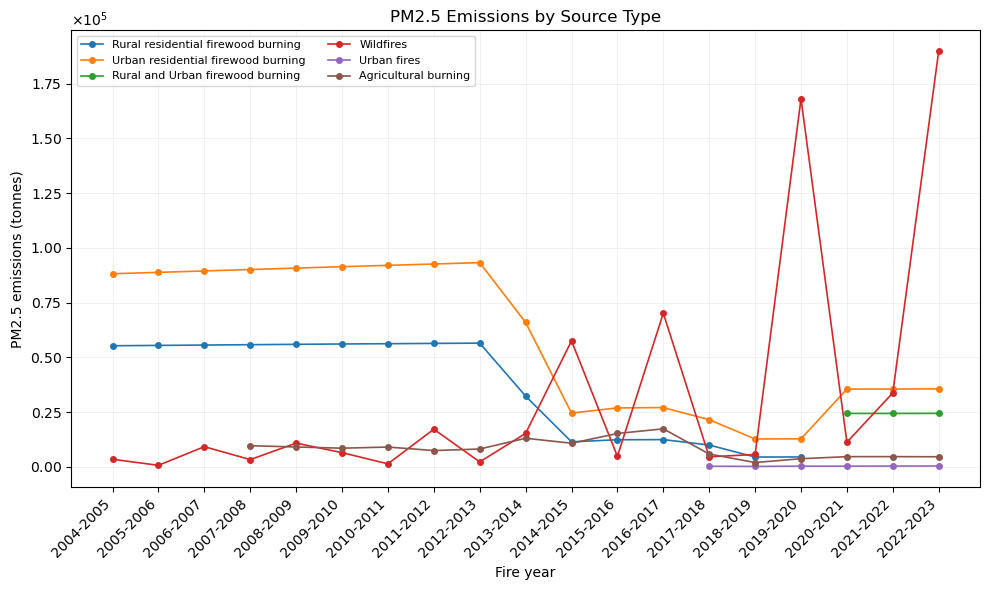

In [33]:
pm25_study_all_sources = combined_clean[
    (combined_clean["contaminante"] == "MP2,5") &
    (combined_clean["region_clean"].isin(study_region))
]

annual_by_source = (
    pm25_study_all_sources.groupby(["fire_year", "tipo_fuente_clean"])["cantidad_toneladas"]
    .sum()
    .unstack("tipo_fuente_clean")
    .sort_index()
)

# Translate source type labels to English for the legend.
source_type_translation = {
    "Fuentes Fijas": "Point sources",
    "Fuentes Móviles": "Mobile sources",
    "Fuentes de Área": "Area sources",
    "Quema de Residuos Agrícolas": "Agricultural waste burning",
    "Incendios Forestales": "Wildfires",
    "Combustión de Leña Residencial Rural": "Rural residential firewood burning",
    "Combustión de Leña Residencial Urbana": "Urban residential firewood burning",
    "Combustión de leña Rural Urbana": "Rural and Urban firewood burning",
    "Incendios Urbanos": "Urban fires",
    "Quemas Agrícolas": "Agricultural burning",
}
annual_by_source = annual_by_source.rename(columns=source_type_translation)

fig, ax = plt.subplots(figsize=(10, 6))
annual_by_source.plot(ax=ax, marker="o", linewidth=1.2, markersize=4)

ax.set_xlabel("Fire year")
ax.set_ylabel("PM2.5 emissions (tonnes)")
ax.set_title("PM2.5 Emissions by Source Type")
ax.legend(fontsize=8, loc="upper left", ncol=2)

# Scientific notation on the y-axis
ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

# Every fire year labelled on the x-axis
ax.set_xticks(range(len(annual_by_source.index)))
ax.set_xticklabels(annual_by_source.index, rotation=45, ha="right")

plt.tight_layout()
ax.grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)
ax.set_axisbelow(True)
plt.savefig("../outputs/pm25_all_sources_timeseries2.png", dpi=400)
plt.show()

## National % Summary

In [34]:
national_total = pm25_all["cantidad_toneladas"].sum()
national_forest_total = pm25_forest_only["cantidad_toneladas"].sum()

def region_summary(label, region_list):
    subset_all = pm25_all[pm25_all["region_clean"].isin(region_list)]
    subset_forest = pm25_forest_only[pm25_forest_only["region_clean"].isin(region_list)]
    total = subset_all["cantidad_toneladas"].sum()
    forest = subset_forest["cantidad_toneladas"].sum()
    return {
        "group": label,
        "total_PM25_tonnes": total,
        "pct_of_national_PM25": 100 * total / national_total,
        "forest_fire_PM25_tonnes": forest,
        "pct_of_group_from_forest_fires": 100 * forest / total if total > 0 else np.nan,
        "pct_of_national_forest_fire_PM25": 100 * forest / national_forest_total if national_forest_total > 0 else np.nan,
    }

summary = pd.DataFrame([
    region_summary("Study region (Ñuble/Biobío/Araucanía)", study_region),
    region_summary("Extended A (+Maule/O'Higgins)", extended_A),
    region_summary("Extended B (+Maule/O'Higgins/Metropolitana/Valparaíso)", extended_B),
    {
        "group": "Whole of Chile",
        "total_PM25_tonnes": national_total,
        "pct_of_national_PM25": 100.0,
        "forest_fire_PM25_tonnes": national_forest_total,
        "pct_of_group_from_forest_fires": 100 * national_forest_total / national_total,
        "pct_of_national_forest_fire_PM25": 100.0,
    },
])

print(summary.to_string(index=False))
summary.to_csv("../outputs/pm25_regional_share_summary.csv", index=False)

                                                 group  total_PM25_tonnes  pct_of_national_PM25  forest_fire_PM25_tonnes  pct_of_group_from_forest_fires  pct_of_national_forest_fire_PM25
                 Study region (Ñuble/Biobío/Araucanía)       2.528226e+06             29.065563             6.152327e+05                       24.334563                         14.463090
                         Extended A (+Maule/O'Higgins)       4.975621e+06             57.201865             2.543018e+06                       51.109553                         59.782088
Extended B (+Maule/O'Higgins/Metropolitana/Valparaíso)       5.768976e+06             66.322614             3.195732e+06                       55.395133                         75.126308
                                        Whole of Chile       8.698355e+06            100.000000             4.253812e+06                       48.903641                        100.000000


In [35]:
display_summary = summary.copy()
display_summary["total_PM25_tonnes"] = display_summary["total_PM25_tonnes"].round(0)
display_summary["forest_fire_PM25_tonnes"] = display_summary["forest_fire_PM25_tonnes"].round(0)
display_summary["pct_of_national_PM25"] = display_summary["pct_of_national_PM25"].round(1)
display_summary["pct_of_group_from_forest_fires"] = display_summary["pct_of_group_from_forest_fires"].round(1)
display_summary["pct_of_national_forest_fire_PM25"] = display_summary["pct_of_national_forest_fire_PM25"].round(1)
display_summary = display_summary.rename(columns={
    "group": "Region grouping",
    "total_PM25_tonnes": "Total PM2.5 (t)",
    "pct_of_national_PM25": "% of national PM2.5",
    "forest_fire_PM25_tonnes": "Forest fire PM2.5 (t)",
    "pct_of_group_from_forest_fires": "% of group's PM2.5 from forest fires",
    "pct_of_national_forest_fire_PM25": "% of national forest-fire PM2.5",
})
styled = (
    display_summary.style
    .format({
        "Total PM2.5 (t)": "{:,.0f}",
        "Forest fire PM2.5 (t)": "{:,.0f}",
        "% of national PM2.5": "{:.1f}%",
        "% of group's PM2.5 from forest fires": "{:.1f}%",
        "% of national forest-fire PM2.5": "{:.1f}%",
    })
    .hide(axis="index")
    .background_gradient(subset=["% of national PM2.5", "% of national forest-fire PM2.5"], cmap="Oranges")
)
styled

Region grouping,Total PM2.5 (t),% of national PM2.5,Forest fire PM2.5 (t),% of group's PM2.5 from forest fires,% of national forest-fire PM2.5
Study region (Ñuble/Biobío/Araucanía),"2,528,226",29.1%,"615,233",24.3%,14.5%
Extended A (+Maule/O'Higgins),"4,975,621",57.2%,"2,543,018",51.1%,59.8%
Extended B (+Maule/O'Higgins/Metropolitana/Valparaíso),"5,768,976",66.3%,"3,195,732",55.4%,75.1%
Whole of Chile,"8,698,355",100.0%,"4,253,812",48.9%,100.0%


## Comparing RETC to FSL, SINCA, GFAS & FINN

### Import and helper functions

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk
from scipy import stats

def is_fire_season(date):
    return date.month in [11, 12, 1, 2, 3]

def assign_fire_year(date):
    if date.month >= 7:
        return date.year
    else:
        return date.year - 1

RETC_FOREST_COLOR = "#5da33d"        #  forest fires only
RETC_FOREST_AGRI_COLOR = "#2ECC71"   # green, forest + agricultural
RETC_ALL_CAUSES_COLOR = "#145A32"    # dark green, all causes

def compare_to_sinca(comparison_df, other_col, other_label, other_units,
                      sinca_col="SINCA_mean", sinca_label="SINCA mean",
                      fire_year_col="fire_year", save_prefix=None, ax=None,
                      other_color_override=None):
    color_map = {
        "FINN": "firebrick",
        "GFAS": "crimson",
        "METHOD1": "#5B7FBF",
        "METHOD2": "#F77F00",
        "METHOD3": "#43AA8B",
        "RETC": RETC_FOREST_COLOR,
    }
    sinca_color = "mediumpurple"
    other_color = other_color_override
    if other_color is None:
        other_color = "dimgrey"
        for key, color in color_map.items():
            if key.upper() in other_label.upper().replace(" ", ""):
                other_color = color
                break

    missing_sinca_years = comparison_df[comparison_df[sinca_col].isna()][fire_year_col].tolist()
    paired = comparison_df.dropna(subset=[sinca_col, other_col]).copy()
    n = len(paired)
    print(f"=== SINCA vs {other_label} (n={n} years) ===")
    mk_sinca = mk.original_test(paired[sinca_col])
    mk_other = mk.original_test(paired[other_col])
    print(f"{sinca_label} trend: p={mk_sinca.p:.4f}, slope={mk_sinca.slope:.4g}, trend={mk_sinca.trend}")
    print(f"{other_label} trend: p={mk_other.p:.4f}, slope={mk_other.slope:.4g}, trend={mk_other.trend}")
    pear = stats.pearsonr(paired[sinca_col], paired[other_col])
    spear = stats.spearmanr(paired[sinca_col], paired[other_col])
    print(f"Pearson r={pear[0]:.3f} (p={pear[1]:.4f}), Spearman r={spear[0]:.3f} (p={spear[1]:.4f})")
    paired["sinca_z"] = (paired[sinca_col] - paired[sinca_col].mean()) / paired[sinca_col].std()
    paired["other_z"] = (paired[other_col] - paired[other_col].mean()) / paired[other_col].std()
    anomalies = paired[(paired["sinca_z"].abs() > 1.5) | (paired["other_z"].abs() > 1.5)]
    print(f"Anomaly years: {anomalies[fire_year_col].tolist()}")

    standalone = ax is None
    if standalone:
        fig, ax1 = plt.subplots(figsize=(14, 5))
    else:
        ax1 = ax
        fig = ax1.figure

    ax2 = ax1.twinx()
    ax1.plot(paired[fire_year_col], paired[sinca_col], color=sinca_color, marker="o", label=sinca_label)
    ax2.plot(paired[fire_year_col], paired[other_col], color=other_color, marker="s", label=other_label)
    ax1.set_ylabel(f"{sinca_label} (µg/m³)", color=sinca_color)
    ax2.set_ylabel(f"{other_label} ({other_units})", color=other_color)
    ax1.set_xlabel("Fire year")
    ax1.set_title(f"SINCA vs {other_label}")
    x_min, x_max = paired[fire_year_col].min(), paired[fire_year_col].max()
    in_range_missing = [y for y in missing_sinca_years if x_min <= y <= x_max]
    all_tick_years = sorted(set(paired[fire_year_col].tolist()) | set(in_range_missing))
    ax1.set_xticks(all_tick_years)
    ax1.set_xticklabels([f"{int(y)}-{int(y)+1}" for y in all_tick_years])
    ax1.tick_params(axis="x", rotation=75)
    for year in in_range_missing:
        ax1.axvline(year, color="grey", linestyle="--", linewidth=1, alpha=0.5)
    ax1.grid(True, which="major", axis="both", color="grey", linestyle="-", linewidth=0.4, alpha=0.3)
    ax1.set_axisbelow(True)

    if standalone:
        fig.tight_layout()
        if save_prefix:
            plt.savefig(f"../outputs/{save_prefix}.png", dpi=150, bbox_inches="tight")
        plt.show()

    return {"label": other_label, "n": n, "mk_sinca": mk_sinca, "mk_other": mk_other,
            "pearson": pear, "spearman": spear, "anomaly_years": anomalies[fire_year_col].tolist(),
            "missing_sinca_years": missing_sinca_years, "paired_df": paired}

def compute_pair_stats(paired, col_a, label_a, col_b, label_b, fire_year_col="fire_year"):
    mk_a = mk.original_test(paired[col_a])
    mk_b = mk.original_test(paired[col_b])
    pear = stats.pearsonr(paired[col_a], paired[col_b])
    spear = stats.spearmanr(paired[col_a], paired[col_b])
    print(f"=== {label_a} vs {label_b} (n={len(paired)}) ===")
    print(f"{label_a} trend: p={mk_a.p:.4f}, slope={mk_a.slope:.4g}, trend={mk_a.trend}")
    print(f"{label_b} trend: p={mk_b.p:.4f}, slope={mk_b.slope:.4g}, trend={mk_b.trend}")
    print(f"Pearson r={pear[0]:.3f} (p={pear[1]:.4f}), Spearman r={spear[0]:.3f} (p={spear[1]:.4f})")
    return {
        "pair": f"{label_a} vs {label_b}", "n": len(paired),
        "mk_a_p": mk_a.p, "mk_a_slope": mk_a.slope, "mk_a_trend": mk_a.trend,
        "mk_b_p": mk_b.p, "mk_b_slope": mk_b.slope, "mk_b_trend": mk_b.trend,
        "pearson_r": pear[0], "pearson_p": pear[1],
        "spearman_r": spear[0], "spearman_p": spear[1],
    }

def plot_pair_panel(ax, paired, col_a, label_a, units_a, color_a,
                     col_b, label_b, units_b, color_b, fire_year_col="fire_year", title=None):
    ax2 = ax.twinx()
    ax.plot(paired[fire_year_col], paired[col_a], color=color_a, marker="o", label=label_a)
    ax2.plot(paired[fire_year_col], paired[col_b], color=color_b, marker="s", label=label_b)
    ax.set_ylabel(f"{label_a} ({units_a})", color=color_a)
    ax2.set_ylabel(f"{label_b} ({units_b})", color=color_b)
    ax.set_xlabel("Fire year")
    ax.set_title(title or f"{label_a} vs {label_b}")
    years = sorted(paired[fire_year_col].tolist())
    ax.set_xticks(years)

In [37]:
method1 = pd.read_csv("../outputs/method1_results.csv")
method2 = pd.read_csv("../outputs/method2_results.csv")
method3 = pd.read_csv("../outputs/method3_percell_results.csv")
gfas_annual = pd.read_csv("../outputs/gfas_pm25_annual_totals.csv")
sinca_annual_flat = pd.read_csv("../outputs/sinca_annual_flat.csv")

method1["fire_year"] = pd.to_datetime(method1["fire_year_start"]).dt.year
method2["fire_year"] = pd.to_datetime(method2["fire_year_start"]).dt.year
method3["fire_year"] = method3["fire_year"].str.split("-").str[0].astype(int)
gfas_annual = gfas_annual.rename(columns={"fire_year_start": "fire_year"})

print("gfas_annual columns:", gfas_annual.columns.tolist())
GFAS_col = "GFAS_sum"  # <-- set this to match the actual column name printed above

finn_daily_full = pd.read_csv("../outputs/finn_pm25_daily_core.csv")
finn_daily_full["date_only"] = pd.to_datetime(finn_daily_full["date"])
finn_daily_full["fire_season"] = finn_daily_full["date_only"].apply(is_fire_season)
finn_daily_full["fire_year"] = finn_daily_full["date_only"].apply(assign_fire_year)
finn_annual_overall = (
    finn_daily_full[finn_daily_full["fire_season"]]
    .groupby("fire_year")
    .agg(FINN_sum=("PM25_kg_day_sum", "sum"))
    .reset_index()
)

sinca_comparison = sinca_annual_flat.rename(
    columns={"SINCA_flat_mean": "SINCA_mean", "SINCA_flat_p95": "SINCA_p95"}
)

gfas_annual columns: ['fire_year', 'pm25_kg_total']


### Build RETC datasets

In [38]:
# fix: fire_year was stored as a season-range string ("2004-2005"); convert to
# the season start year as an int64 so it merges cleanly with the other frames
if pm25_study_all_sources["fire_year"].dtype == object:
    pm25_study_all_sources["fire_year"] = pm25_study_all_sources["fire_year"].str.split("-").str[0].astype("int64")

print(pm25_study_all_sources["fire_year"].dtype, pm25_study_all_sources["fire_year"].unique()[:5])

agri_labels_all_variants = ["Quemas Agricolas", "Quemas Agrícolas"]
found_agri_labels = [l for l in pm25_study_all_sources["tipo_fuente_clean"].unique() if l in agri_labels_all_variants]
print("Agricultural burning labels found in tipo_fuente_clean:", found_agri_labels)

forest_agri_mask = pm25_study_all_sources["tipo_fuente_clean"].isin([forest_label] + found_agri_labels)

retc_annual_forest = (
    pm25_study_all_sources[pm25_study_all_sources["tipo_fuente_clean"] == forest_label]
    .groupby("fire_year")["cantidad_toneladas"]
    .sum()
    .reset_index()
    .rename(columns={"cantidad_toneladas": "RETC_forest_tonnes"})
)

retc_annual_forest_agri = (
    pm25_study_all_sources[forest_agri_mask]
    .groupby("fire_year")["cantidad_toneladas"]
    .sum()
    .reset_index()
    .rename(columns={"cantidad_toneladas": "RETC_forest_agri_tonnes"})
)

retc_annual_all_causes = (
    pm25_study_all_sources
    .groupby("fire_year")["cantidad_toneladas"]
    .sum()
    .reset_index()
    .rename(columns={"cantidad_toneladas": "RETC_all_causes_tonnes"})
)

print(retc_annual_forest.head())
print(retc_annual_forest_agri.head())
print(retc_annual_all_causes.head())

int64 [2004 2005 2006 2007 2008]
Agricultural burning labels found in tipo_fuente_clean: ['Quemas Agrícolas']
   fire_year  RETC_forest_tonnes
0       2004         3427.460132
1       2005          671.729233
2       2006         9188.002022
3       2007         3279.917169
4       2008        10817.593616
   fire_year  RETC_forest_agri_tonnes
0       2004              3427.460132
1       2005               671.729233
2       2006              9188.002022
3       2007             12910.343785
4       2008             19856.608952
   fire_year  RETC_all_causes_tonnes
0       2004           146860.381477
1       2005           144911.231528
2       2006           154233.119818
3       2007           158763.863878
4       2008           166517.490716


/tmp/ipykernel_448644/3976592200.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pm25_study_all_sources["fire_year"] = pm25_study_all_sources["fire_year"].str.split("-").str[0].astype("int64")


In [39]:
for name, df in [("retc_annual_forest", retc_annual_forest),
                  ("retc_annual_forest_agri", retc_annual_forest_agri),
                  ("retc_annual_all_causes", retc_annual_all_causes),
                  ("pm25_study_all_sources", pm25_study_all_sources)]:
    print(f"{name}: dtype={df['fire_year'].dtype}, sample={df['fire_year'].head(3).tolist()}")

retc_annual_forest: dtype=int64, sample=[2004, 2005, 2006]
retc_annual_forest_agri: dtype=int64, sample=[2004, 2005, 2006]
retc_annual_all_causes: dtype=int64, sample=[2004, 2005, 2006]
pm25_study_all_sources: dtype=int64, sample=[2004, 2004, 2004]


In [40]:
print(pm25_study_all_sources["fire_year"].head(5).tolist())
print(pm25_study_all_sources["fire_year"].unique()[:5])

[2004, 2004, 2004, 2004, 2004]
[2004 2005 2006 2007 2008]


In [41]:
# Master Comparison Table
sinca_comparison = sinca_annual_flat.rename(
    columns={"SINCA_flat_mean": "SINCA_mean", "SINCA_flat_p95": "SINCA_p95"}
)

comparison_retc = retc_annual_forest.merge(retc_annual_forest_agri, on="fire_year", how="outer")
comparison_retc = comparison_retc.merge(retc_annual_all_causes, on="fire_year", how="outer")
comparison_retc = comparison_retc.merge(
    method1[["fire_year", "season_length_days"]].rename(columns={"season_length_days": "method1_length"}),
    on="fire_year", how="outer")
comparison_retc = comparison_retc.merge(
    method2[["fire_year", "season_length_days"]].rename(columns={"season_length_days": "method2_length"}),
    on="fire_year", how="outer")
comparison_retc = comparison_retc.merge(method3[["fire_year", "fsl_p90_median"]], on="fire_year", how="outer")
comparison_retc = comparison_retc.merge(sinca_comparison[["fire_year", "SINCA_mean"]], on="fire_year", how="outer")
comparison_retc = comparison_retc.merge(gfas_annual[["fire_year", "pm25_kg_total"]], on="fire_year", how="outer")
comparison_retc = comparison_retc.merge(finn_annual_overall, on="fire_year", how="outer")
comparison_retc = comparison_retc.sort_values("fire_year").reset_index(drop=True)

units_map = {
    "fire_year": "season start year",
    "RETC_forest_tonnes": "tonnes",
    "RETC_forest_agri_tonnes": "tonnes",
    "RETC_all_causes_tonnes": "tonnes",
    "method1_length": "days",
    "method2_length": "days",
    "fsl_p90_median": "days",
    "SINCA_mean": "µg/m³",
    GFAS_col: "kg",
    "FINN_sum": "kg",
}

comparison_retc_display = comparison_retc.rename(
    columns={col: f"{col} ({unit})" for col, unit in units_map.items() if col in comparison_retc.columns}
)
print(comparison_retc_display)
comparison_retc_display.to_csv("../outputs/retc_master_comparison_table.csv", index=False)

    fire_year (season start year)  RETC_forest_tonnes (tonnes)  \
0                            2002                          NaN   
1                            2003                          NaN   
2                            2004                  3427.460132   
3                            2005                   671.729233   
4                            2006                  9188.002022   
5                            2007                  3279.917169   
6                            2008                 10817.593616   
7                            2009                  6444.274657   
8                            2010                  1354.485057   
9                            2011                 17148.416625   
10                           2012                  2228.787133   
11                           2013                 15240.558063   
12                           2014                 57509.129919   
13                           2015                  4775.674921   
14        

### RETC (forest only) vs FSL 3 methods — 3-panel figure (2003/04–2022/23)

=== RETC forest vs Method 1 (n=19) ===
RETC forest trend: p=0.0064, slope=1659, trend=increasing
Method 1 trend: p=0.0041, slope=4.857, trend=increasing
Pearson r=0.227 (p=0.3508), Spearman r=0.042 (p=0.8640)
=== RETC forest vs Method 2 (n=19) ===
RETC forest trend: p=0.0064, slope=1659, trend=increasing
Method 2 trend: p=0.3815, slope=-1.182, trend=no trend
Pearson r=-0.351 (p=0.1406), Spearman r=-0.575 (p=0.0100)
=== RETC forest vs Method 3 (n=19) ===
RETC forest trend: p=0.0064, slope=1659, trend=increasing
Method 3 trend: p=0.0063, slope=3.067, trend=increasing
Pearson r=0.628 (p=0.0040), Spearman r=0.665 (p=0.0019)


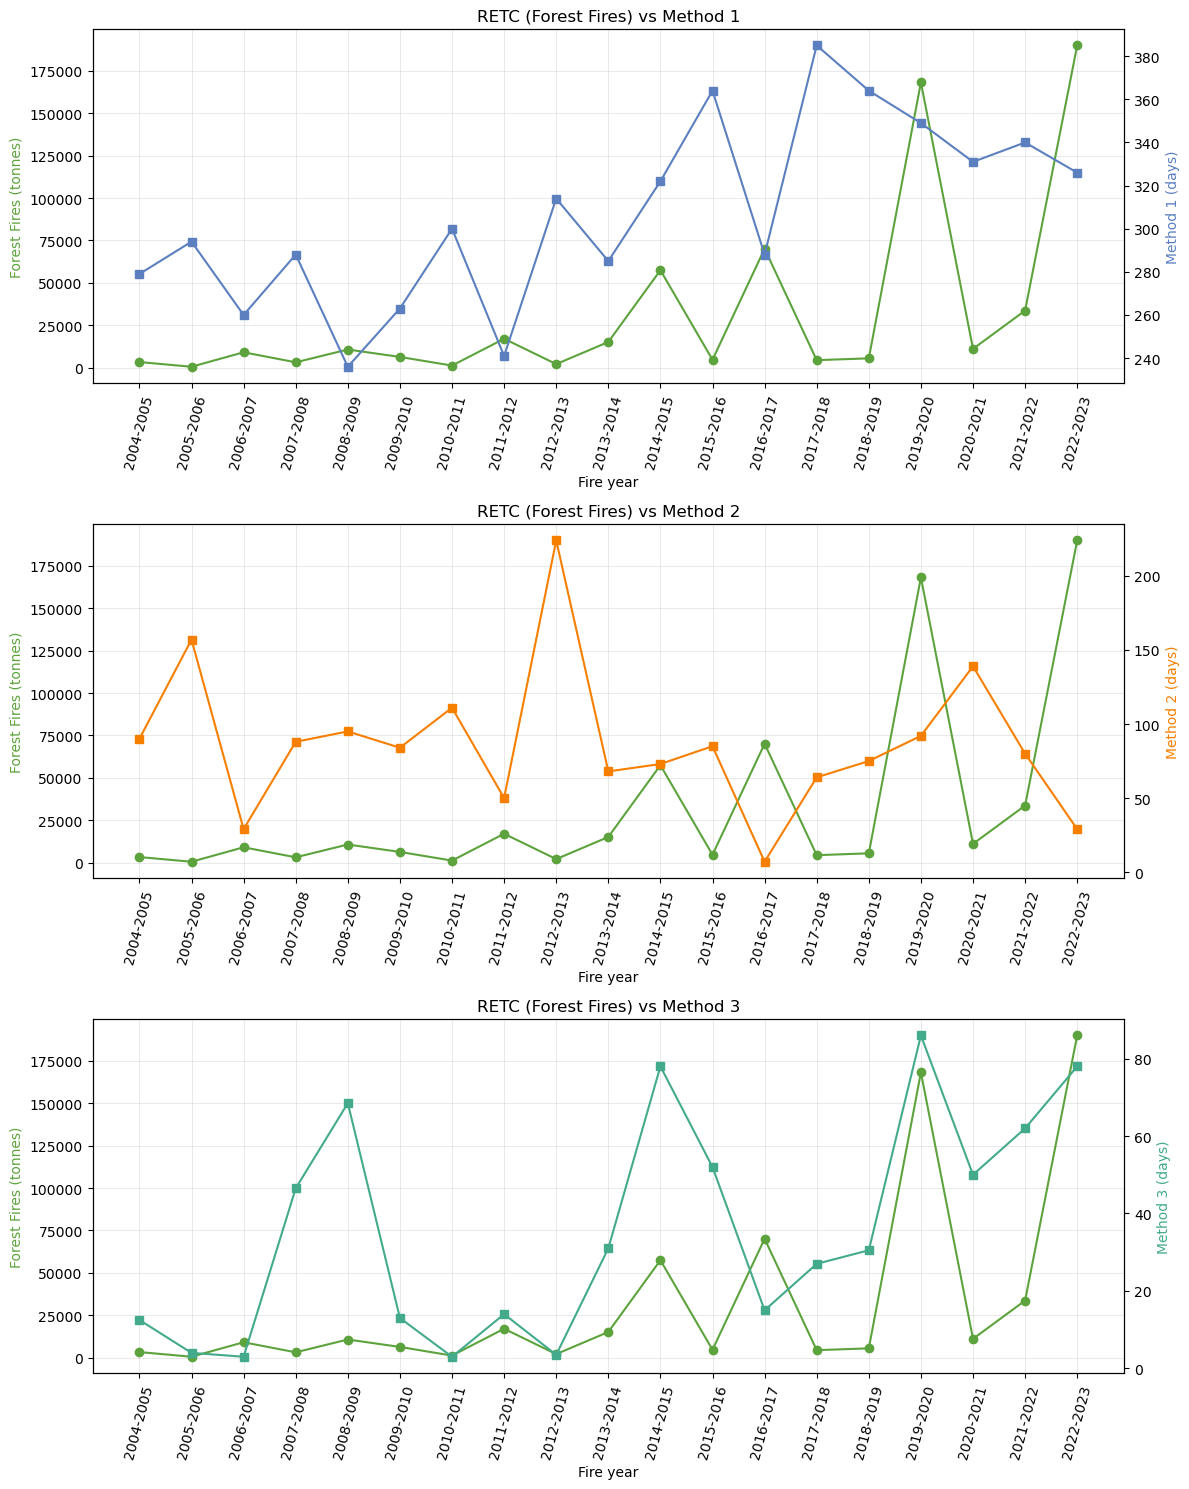

                   pair  n   mk_a_p  mk_a_slope mk_a_trend   mk_b_p  mk_b_slope mk_b_trend  pearson_r  pearson_p  spearman_r  spearman_p
RETC forest vs Method 1 19 0.006355 1659.306042 increasing 0.004075    4.857143 increasing   0.226627   0.350821    0.042142    0.863989
RETC forest vs Method 2 19 0.006355 1659.306042 increasing 0.381479   -1.181818   no trend  -0.350994   0.140633   -0.574814    0.010040
RETC forest vs Method 3 19 0.006355 1659.306042 increasing 0.006291    3.066667 increasing   0.628160   0.003976    0.664618    0.001908


In [42]:
retc_fsl3 = comparison_retc[(comparison_retc["fire_year"] >= 2003) & (comparison_retc["fire_year"] <= 2022)].copy()

fsl_specs = [
    ("method1_length", "Method 1", "days", "#5B7FBF"),
    ("method2_length", "Method 2", "days", "#F77F00"),
    ("fsl_p90_median", "Method 3", "days", "#43AA8B"),
]

def plot_retc_fsl_panel(ax, paired, retc_col, retc_label, retc_color, other_col, other_label, other_units, other_color):
    ax2 = ax.twinx()
    ax.plot(paired["fire_year"], paired[retc_col], color=retc_color, marker="o", label=retc_label)
    ax2.plot(paired["fire_year"], paired[other_col], color=other_color, marker="s", label=other_label)
    ax.set_ylabel(f"{retc_label} (tonnes)", color=retc_color)
    ax2.set_ylabel(f"{other_label} ({other_units})", color=other_color)
    ax.set_xlabel("Fire year")
    ax.set_title(f"RETC ({retc_label}) vs {other_label}")
    years = sorted(paired["fire_year"].tolist())
    ax.set_xticks(years)
    ax.set_xticklabels([f"{int(y)}-{int(y)+1}" for y in years])
    ax.tick_params(axis="x", rotation=75)
    ax.grid(True, which="major", axis="both", color="grey", linestyle="-", linewidth=0.4, alpha=0.3)
    ax.set_axisbelow(True)

fig, axes = plt.subplots(3, 1, figsize=(12, 15))
stats_rows = []
for ax, (col, label, units, color) in zip(axes, fsl_specs):
    paired = retc_fsl3.dropna(subset=["RETC_forest_tonnes", col])
    plot_retc_fsl_panel(ax, paired, "RETC_forest_tonnes", "Forest Fires", RETC_FOREST_COLOR, col, label, units, color)
    stats_rows.append(compute_pair_stats(paired, "RETC_forest_tonnes", "RETC forest", col, label))

fig.tight_layout()
plt.savefig("../outputs/retc_forest_vs_fsl3methods_timeseries.png", dpi=400)
plt.show()

retc_fsl3_stats = pd.DataFrame(stats_rows)
retc_fsl3_stats.to_csv("../outputs/retc_forest_vs_fsl3methods_stats.csv", index=False)
print(retc_fsl3_stats.to_string(index=False))

### RETC (forest only) vs Method 3 only — single panel (2003/04–2022/23)

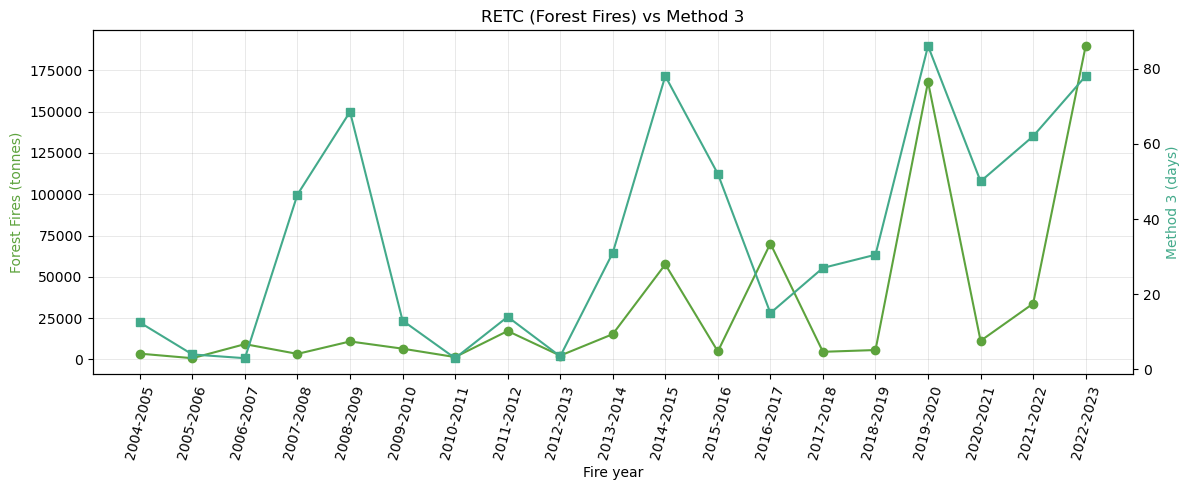

=== RETC forest vs Method 3 (n=19) ===
RETC forest trend: p=0.0064, slope=1659, trend=increasing
Method 3 trend: p=0.0063, slope=3.067, trend=increasing
Pearson r=0.628 (p=0.0040), Spearman r=0.665 (p=0.0019)


In [43]:
paired_m3 = retc_fsl3.dropna(subset=["RETC_forest_tonnes", "fsl_p90_median"])

fig, ax = plt.subplots(figsize=(12, 5))
plot_retc_fsl_panel(ax, paired_m3, "RETC_forest_tonnes", "Forest Fires", RETC_FOREST_COLOR,
                     "fsl_p90_median", "Method 3", "days", "#43AA8B")
fig.tight_layout()
plt.savefig("../outputs/retc_forest_vs_method3_timeseries.png", dpi=400)
plt.show()

retc_m3_stats = compute_pair_stats(paired_m3, "RETC_forest_tonnes", "RETC forest", "fsl_p90_median", "Method 3")
pd.DataFrame([retc_m3_stats]).to_csv("../outputs/retc_forest_vs_method3_stats.csv", index=False)

### RETC vs SINCA — forest only, and all causes (2004/05–2022/23)

=== SINCA vs RETC forest fires (n=15 years) ===
SINCA mean trend: p=0.0294, slope=-0.3269, trend=decreasing
RETC forest fires trend: p=0.0600, slope=2216, trend=no trend
Pearson r=-0.226 (p=0.4181), Spearman r=-0.161 (p=0.5672)
Anomaly years: [2013, 2019, 2022]


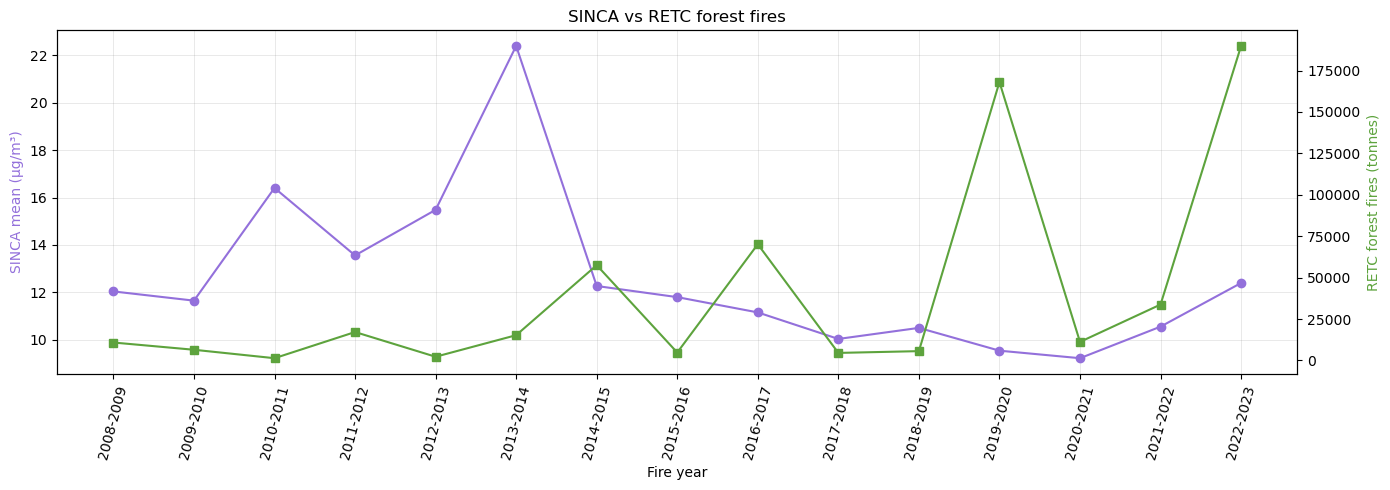

=== SINCA vs RETC all causes (n=15 years) ===
SINCA mean trend: p=0.0294, slope=-0.3269, trend=decreasing
RETC all causes trend: p=0.1982, slope=-5456, trend=no trend
Pearson r=0.242 (p=0.3848), Spearman r=0.379 (p=0.1641)
Anomaly years: [2013, 2018, 2022]


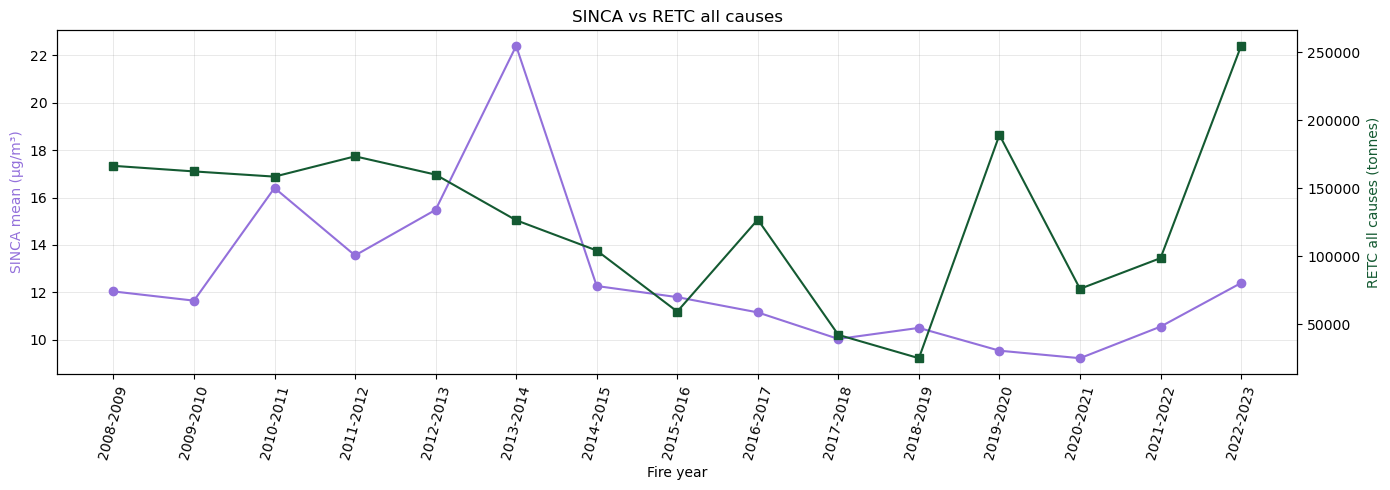

In [44]:
retc_sinca_input = comparison_retc[(comparison_retc["fire_year"] >= 2004) & (comparison_retc["fire_year"] <= 2022)].copy()

retc_sinca_forest_result = compare_to_sinca(
    retc_sinca_input,
    other_col="RETC_forest_tonnes",
    other_label="RETC forest fires",
    other_units="tonnes",
    other_color_override=RETC_FOREST_COLOR,
    save_prefix="retc_forest_vs_sinca_timeseries"
)

retc_sinca_all_result = compare_to_sinca(
    retc_sinca_input,
    other_col="RETC_all_causes_tonnes",
    other_label="RETC all causes",
    other_units="tonnes",
    other_color_override=RETC_ALL_CAUSES_COLOR,
    save_prefix="retc_all_causes_vs_sinca_timeseries"
)

### RETC vs FINN and GFAS — forest only, and forest+agricultural (2003/04–2022/23)

=== RETC forest vs FINN (n=19) ===
RETC forest trend: p=0.0064, slope=1659, trend=increasing
FINN trend: p=0.0021, slope=2.827e+06, trend=increasing
Pearson r=0.803 (p=0.0000), Spearman r=0.874 (p=0.0000)
=== RETC forest vs GFAS (n=19) ===
RETC forest trend: p=0.0064, slope=1659, trend=increasing
GFAS trend: p=0.4415, slope=3.304e+05, trend=no trend
Pearson r=0.740 (p=0.0003), Spearman r=0.577 (p=0.0097)


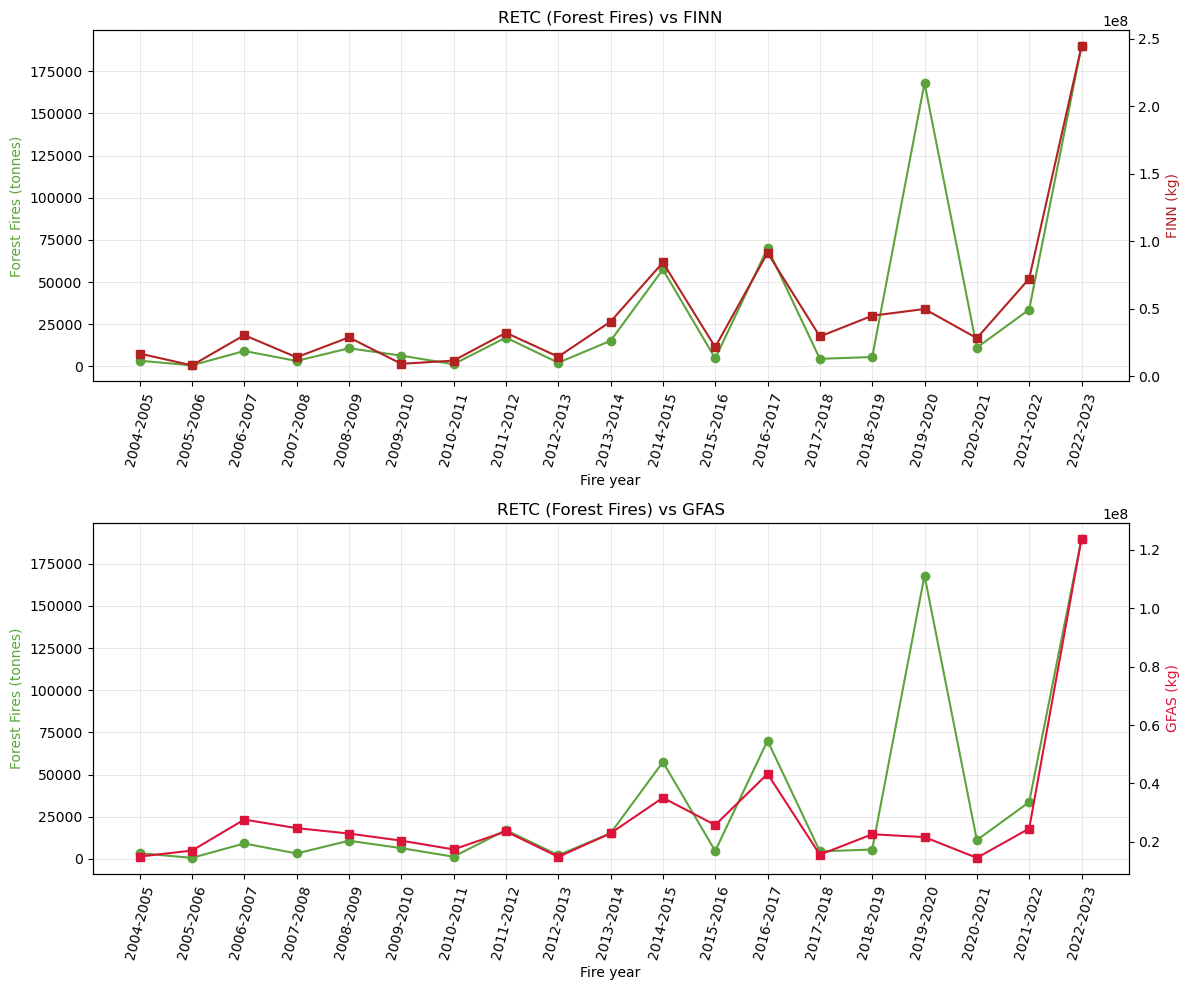

               pair  n   mk_a_p  mk_a_slope mk_a_trend   mk_b_p   mk_b_slope mk_b_trend  pearson_r  pearson_p  spearman_r  spearman_p
RETC forest vs FINN 19 0.006355 1659.306042 increasing 0.002079 2.826702e+06 increasing   0.803087   0.000035    0.873684    0.000001
RETC forest vs GFAS 19 0.006355 1659.306042 increasing 0.441488 3.303675e+05   no trend   0.740114   0.000291    0.577193    0.009665
=== RETC forest+agri vs FINN (n=19) ===
RETC forest+agri trend: p=0.0033, slope=2546, trend=increasing
FINN trend: p=0.0021, slope=2.827e+06, trend=increasing
Pearson r=0.805 (p=0.0000), Spearman r=0.723 (p=0.0005)
=== RETC forest+agri vs GFAS (n=19) ===
RETC forest+agri trend: p=0.0033, slope=2546, trend=increasing
GFAS trend: p=0.4415, slope=3.304e+05, trend=no trend
Pearson r=0.743 (p=0.0003), Spearman r=0.595 (p=0.0072)


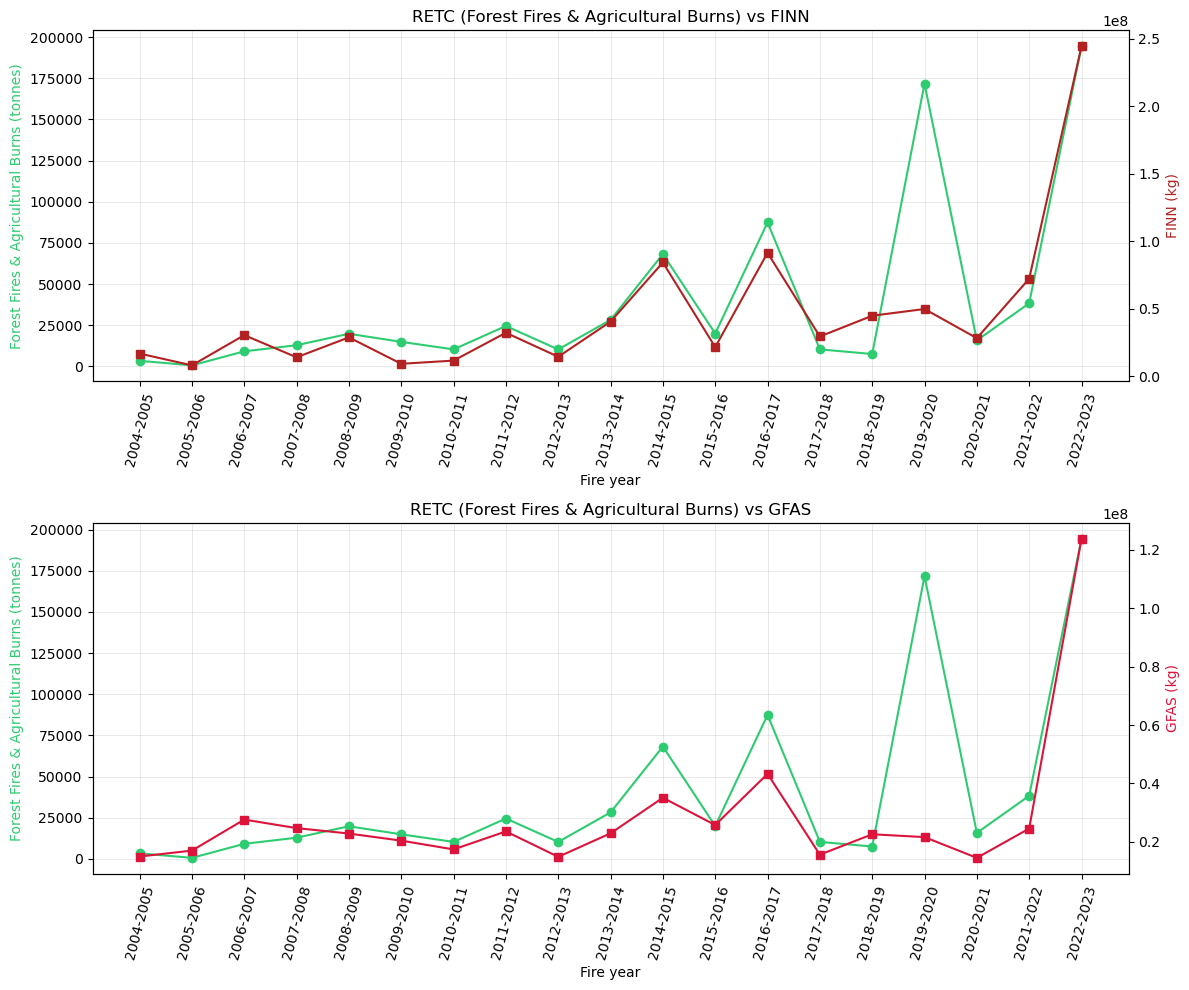

                    pair  n   mk_a_p  mk_a_slope mk_a_trend   mk_b_p   mk_b_slope mk_b_trend  pearson_r  pearson_p  spearman_r  spearman_p
RETC forest+agri vs FINN 19 0.003295 2545.996317 increasing 0.002079 2.826702e+06 increasing   0.805300   0.000032    0.722807    0.000472
RETC forest+agri vs GFAS 19 0.003295 2545.996317 increasing 0.441488 3.303675e+05   no trend   0.743486   0.000264    0.594737    0.007235


In [45]:
retc_inventories = comparison_retc[(comparison_retc["fire_year"] >= 2003) & (comparison_retc["fire_year"] <= 2022)].copy()

inv_specs = [
    ("FINN_sum", "FINN", "kg", "firebrick"),
    ("pm25_kg_total", "GFAS", "kg", "crimson"),
]

def plot_retc_inventory_panel(ax, paired, retc_col, retc_label, retc_color, other_col, other_label, other_units, other_color):
    ax2 = ax.twinx()
    ax.plot(paired["fire_year"], paired[retc_col], color=retc_color, marker="o", label=retc_label)
    ax2.plot(paired["fire_year"], paired[other_col], color=other_color, marker="s", label=other_label)
    ax.set_ylabel(f"{retc_label} (tonnes)", color=retc_color)
    ax2.set_ylabel(f"{other_label} ({other_units})", color=other_color)
    ax.set_xlabel("Fire year")
    ax.set_title(f"RETC ({retc_label}) vs {other_label}")
    years = sorted(paired["fire_year"].tolist())
    ax.set_xticks(years)
    ax.set_xticklabels([f"{int(y)}-{int(y)+1}" for y in years])
    ax.tick_params(axis="x", rotation=75)
    ax.grid(True, which="major", axis="both", color="grey", linestyle="-", linewidth=0.4, alpha=0.3)
    ax.set_axisbelow(True)

# --- Forest fires only ---
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
inv_stats_forest_rows = []
for ax, (col, label, units, color) in zip(axes, inv_specs):
    paired = retc_inventories.dropna(subset=["RETC_forest_tonnes", col])
    plot_retc_inventory_panel(ax, paired, "RETC_forest_tonnes", "Forest Fires", RETC_FOREST_COLOR, col, label, units, color)
    inv_stats_forest_rows.append(compute_pair_stats(paired, "RETC_forest_tonnes", "RETC forest", col, label))

fig.tight_layout()
plt.savefig("../outputs/retc_forest_vs_finn_gfas_timeseries.png", dpi=400)
plt.show()

retc_inv_forest_stats = pd.DataFrame(inv_stats_forest_rows)
retc_inv_forest_stats.to_csv("../outputs/retc_forest_vs_finn_gfas_stats.csv", index=False)
print(retc_inv_forest_stats.to_string(index=False))

# --- Forest + agricultural ---
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
inv_stats_forest_agri_rows = []
for ax, (col, label, units, color) in zip(axes, inv_specs):
    paired = retc_inventories.dropna(subset=["RETC_forest_agri_tonnes", col])
    plot_retc_inventory_panel(ax, paired, "RETC_forest_agri_tonnes", "Forest Fires & Agricultural Burns", RETC_FOREST_AGRI_COLOR, col, label, units, color)
    inv_stats_forest_agri_rows.append(compute_pair_stats(paired, "RETC_forest_agri_tonnes", "RETC forest+agri", col, label))

fig.tight_layout()
plt.savefig("../outputs/retc_forest_agri_vs_finn_gfas_timeseries.png", dpi=400)
plt.show()

retc_inv_forest_agri_stats = pd.DataFrame(inv_stats_forest_agri_rows)
retc_inv_forest_agri_stats.to_csv("../outputs/retc_forest_agri_vs_finn_gfas_stats.csv", index=False)
print(retc_inv_forest_agri_stats.to_string(index=False))